<a href="https://colab.research.google.com/github/Kishore-CP54/Development-of-a-Healthcare-Operations-Intelligence-Dashboard-with-Decision-Analytics/blob/main/Project%20Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

# HEALTHCARE OPERATIONS INTELLIGENCE DASHBOARD
# Project Presenter: Kishore C P
# Platform: Google Colab
# Note: Uses synthetic sample data, not real patient records.

!pip -q install pandas plotly

import pandas as pd
import numpy as np
import plotly.express as px
from IPython.display import display, Markdown
from datetime import date, timedelta

# --------------------------------------------------
# 1. GENERATE SAMPLE HEALTHCARE OPERATIONS DATA
# --------------------------------------------------

np.random.seed(42)

departments = [
    "Emergency", "Cardiology", "Neurology",
    "Orthopedics", "General Medicine", "Pediatrics"
]

records = []
start_date = date(2026, 1, 1)

for i in range(540):
    department = np.random.choice(departments)
    day = start_date + timedelta(days=int(np.random.randint(0, 90)))

    admissions = int(np.random.randint(8, 45))
    discharges = max(
        0, admissions - int(np.random.randint(-5, 9))
    )

    occupancy = round(float(np.clip(
        np.random.normal(
            86 if department == "Emergency" else 76, 12
        ), 35, 100
    )), 1)

    wait_time = round(float(np.clip(
        np.random.normal(
            68 if department == "Emergency" else 32, 18
        ), 5, 150
    )), 1)

    records.append({
        "Date": day,
        "Department": department,
        "Admissions": admissions,
        "Discharges": discharges,
        "Occupancy (%)": occupancy,
        "Waiting Time (minutes)": wait_time,
        "Staff On Duty": int(np.random.randint(8, 30)),
        "Incidents": int(np.random.poisson(
            1.0 if department == "Emergency" else 0.45
        ))
    })

df = pd.DataFrame(records).sort_values("Date")

# Downloadable dataset
df.to_csv("healthcare_operations.csv", index=False)

display(Markdown("# Healthcare Operations Intelligence Dashboard"))
display(Markdown(
    "**Project:** Development of a Healthcare Operations "
    "Intelligence Dashboard with Decision Analytics  \n"
    "**Presenter:** Kishore C P  \n"
    "**Data:** Synthetic demonstration records"
))

# --------------------------------------------------
# 2. FILTER DATA BY DEPARTMENT
# --------------------------------------------------

department_choice = "All Departments"

# Change the value above to "Emergency", "Cardiology",
# "Neurology", "Orthopedics", "General Medicine", or "Pediatrics"

if department_choice == "All Departments":
    data = df.copy()
else:
    data = df[df["Department"] == department_choice].copy()

# --------------------------------------------------
# 3. KEY PERFORMANCE INDICATORS
# --------------------------------------------------

total_admissions = int(data["Admissions"].sum())
total_discharges = int(data["Discharges"].sum())
average_occupancy = round(data["Occupancy (%)"].mean(), 2)
average_waiting = round(data["Waiting Time (minutes)"].mean(), 2)
total_incidents = int(data["Incidents"].sum())

kpis = pd.DataFrame({
    "Metric": [
        "Total Admissions",
        "Total Discharges",
        "Average Occupancy (%)",
        "Average Waiting Time (minutes)",
        "Total Reported Incidents"
    ],
    "Value": [
        total_admissions,
        total_discharges,
        average_occupancy,
        average_waiting,
        total_incidents
    ]
})

display(Markdown("## 1. Key Performance Indicators"))
display(kpis)

# --------------------------------------------------
# 4. ADMISSIONS AND DISCHARGES TREND
# --------------------------------------------------

display(Markdown("## 2. Patient Flow Analysis"))

daily_flow = data.groupby("Date", as_index=False)[
    ["Admissions", "Discharges"]
].sum()

fig1 = px.line(
    daily_flow,
    x="Date",
    y=["Admissions", "Discharges"],
    markers=True,
    title="Daily Admissions vs Discharges",
    labels={"value": "Patient Count", "variable": "Metric"}
)

fig1.show()

# --------------------------------------------------
# 5. DEPARTMENT OCCUPANCY ANALYSIS
# --------------------------------------------------

display(Markdown("## 3. Department Occupancy Analysis"))

department_summary = df.groupby("Department", as_index=False).agg(
    Average_Occupancy=("Occupancy (%)", "mean"),
    Average_Waiting_Time=("Waiting Time (minutes)", "mean"),
    Total_Admissions=("Admissions", "sum"),
    Total_Incidents=("Incidents", "sum")
)

department_summary["Average_Occupancy"] = (
    department_summary["Average_Occupancy"].round(2)
)
department_summary["Average_Waiting_Time"] = (
    department_summary["Average_Waiting_Time"].round(2)
)

fig2 = px.bar(
    department_summary,
    x="Department",
    y="Average_Occupancy",
    color="Average_Occupancy",
    title="Average Occupancy by Department",
    labels={"Average_Occupancy": "Average Occupancy (%)"}
)

fig2.add_hline(
    y=85,
    line_dash="dash",
    annotation_text="85% Review Threshold"
)

fig2.show()
display(department_summary)

# --------------------------------------------------
# 6. STAFFING AND RESOURCE ANALYSIS
# --------------------------------------------------

display(Markdown("## 4. Staffing and Resource Analysis"))

resource_summary = df.groupby("Department", as_index=False).agg(
    Average_Staff=("Staff On Duty", "mean"),
    Average_Occupancy=("Occupancy (%)", "mean")
)

resource_summary["Average_Staff"] = (
    resource_summary["Average_Staff"].round(1)
)

fig3 = px.bar(
    resource_summary,
    x="Department",
    y="Average_Staff",
    title="Average Staff on Duty by Department",
    color="Average_Staff",
    labels={"Average_Staff": "Average Staff on Duty"}
)

fig3.show()
display(resource_summary)

# --------------------------------------------------
# 7. DECISION ANALYTICS AND ALERTS
# --------------------------------------------------

display(Markdown("## 5. Decision Analytics and Alerts"))

alerts = []

for _, row in department_summary.iterrows():

    if row["Average_Occupancy"] >= 85:
        alerts.append({
            "Department": row["Department"],
            "Priority": "High",
            "Issue": "High average occupancy",
            "Suggested Action":
                "Review resource availability and staffing."
        })

    if row["Average_Waiting_Time"] >= 60:
        alerts.append({
            "Department": row["Department"],
            "Priority": "High",
            "Issue": "Long average waiting time",
            "Suggested Action":
                "Review patient flow and peak-hour coverage."
        })

    if row["Total_Incidents"] >= 60:
        alerts.append({
            "Department": row["Department"],
            "Priority": "Medium",
            "Issue": "Incident count requires review",
            "Suggested Action":
                "Review incident trends and documentation."
        })

if alerts:
    alert_table = pd.DataFrame(alerts).drop_duplicates()
    display(alert_table)
else:
    display(Markdown("No alerts triggered by the sample data."))

# --------------------------------------------------
# 8. OVERALL SUMMARY
# --------------------------------------------------

display(Markdown("## 6. Project Summary"))

print("Total records:", len(df))
print("Departments analysed:", df["Department"].nunique())
print("Total admissions:", total_admissions)
print("Average occupancy:", average_occupancy, "%")
print("Average waiting time:", average_waiting, "minutes")
print("Total reported incidents:", total_incidents)

display(Markdown(
    "**Conclusion:** This demonstration uses operational KPIs, "
    "trend charts, department comparisons, and simple rule-based "
    "alerts to help identify areas for operational review."
))

display(Markdown(
    "**Important:** The data is synthetic. Alerts are illustrative "
    "rules, not clinical recommendations. This is not a predictive "
    "machine-learning model or a clinical decision-support system."
))

# --------------------------------------------------
# 9. DOWNLOAD DATASET
# --------------------------------------------------

from google.colab import files
files.download("healthcare_operations.csv")


# Healthcare Operations Intelligence Dashboard

**Project:** Development of a Healthcare Operations Intelligence Dashboard with Decision Analytics  
**Presenter:** Kishore C P  
**Data:** Synthetic demonstration records

## 1. Key Performance Indicators

,Metric,Value
0,Total Admissions,14398.00
1,Total Discharges,13457.00
2,Average Occupancy (%),77.82
3,Average Waiting Time (minutes),40.43
4,Total Reported Incidents,303.00


## 2. Patient Flow Analysis

...

Total records: 540
Departments analysed: 6
Total admissions: 14398
Average occupancy: 77.82 %
Average waiting time: 40.43 minutes
Total reported incidents: 303


**Conclusion:** This demonstration uses operational KPIs, trend charts, department comparisons, and simple rule-based alerts to help identify areas for operational review.

**Important:** The data is synthetic. Alerts are illustrative rules, not clinical recommendations. This is not a predictive machine-learning model or a clinical decision-support system.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Healthcare Operations Dataset


,Date,Department,Admissions,Discharges,Occupancy,Waiting_Time,Staff_On_Duty,Incidents
0,2026-01-01,Orthopedics,10,20,67,41,7,3
1,2026-01-02,General Medicine,36,14,96,43,13,1
2,2026-01-03,Neurology,22,43,61,101,17,2
3,2026-01-04,General Medicine,12,27,58,104,22,2
4,2026-01-05,General Medicine,48,8,59,81,19,4


Total Records: 180
Departments: 6
Missing Values:
Date             0
Department       0
Admissions       0
Discharges       0
Occupancy        0
Waiting_Time     0
Staff_On_Duty    0
Incidents        0
dtype: int64

--- HEALTHCARE KPI SUMMARY ---
Total Admissions: 5560
Total Discharges: 4979
Average Occupancy: 74.17 %
Average Waiting Time: 65.07 minutes
Average Staff on Duty: 13.47
Total Reported Incidents: 443

--- DEPARTMENT PERFORMANCE ---


,Total_Admissions,Total_Discharges,Average_Occupancy,Average_Waiting_Time,Average_Staff,Total_Incidents
Department,,,,,,
Cardiology,787,784,78.36,66.07,14.29,67
Emergency,834,702,72.85,49.07,12.48,86
General Medicine,1036,736,68.97,70.03,16.03,84
Neurology,761,829,76.19,61.26,13.15,56
Orthopedics,1259,1161,75.03,71.75,14.02,74
Pediatrics,883,767,73.68,68.32,10.39,76


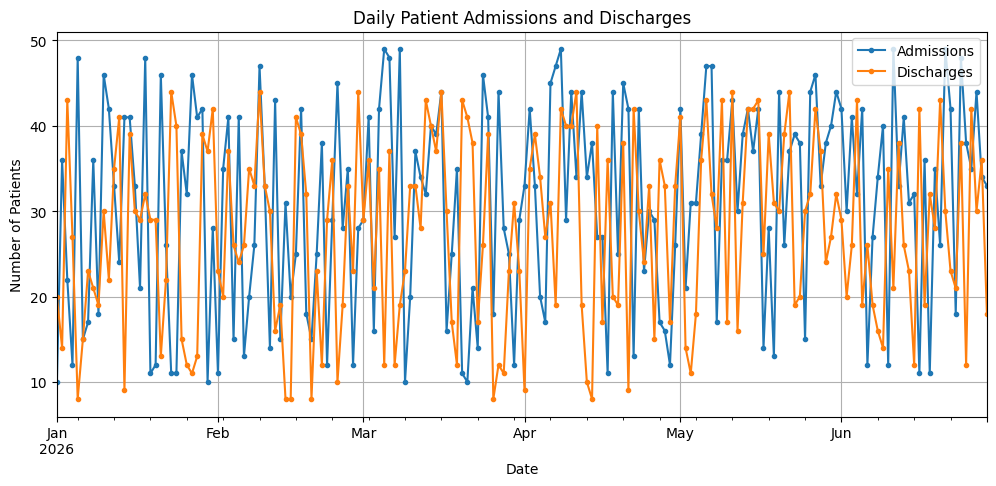

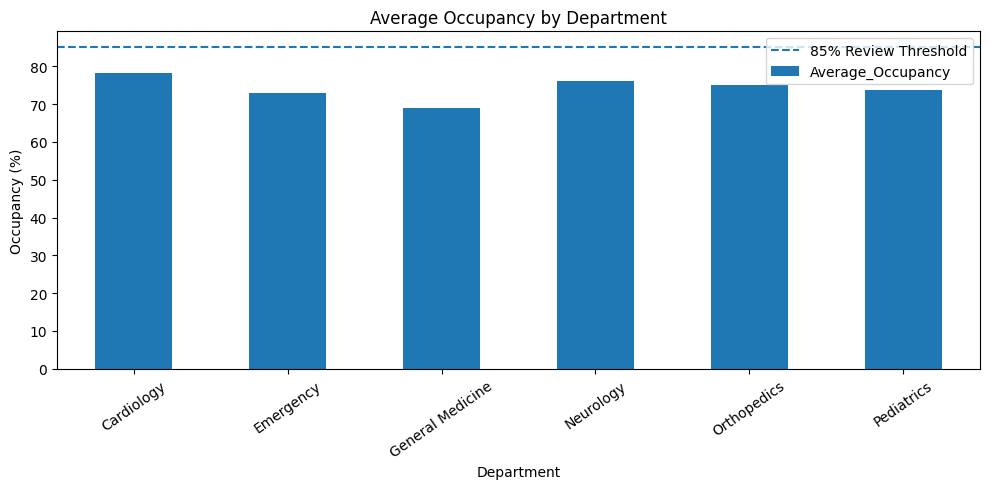

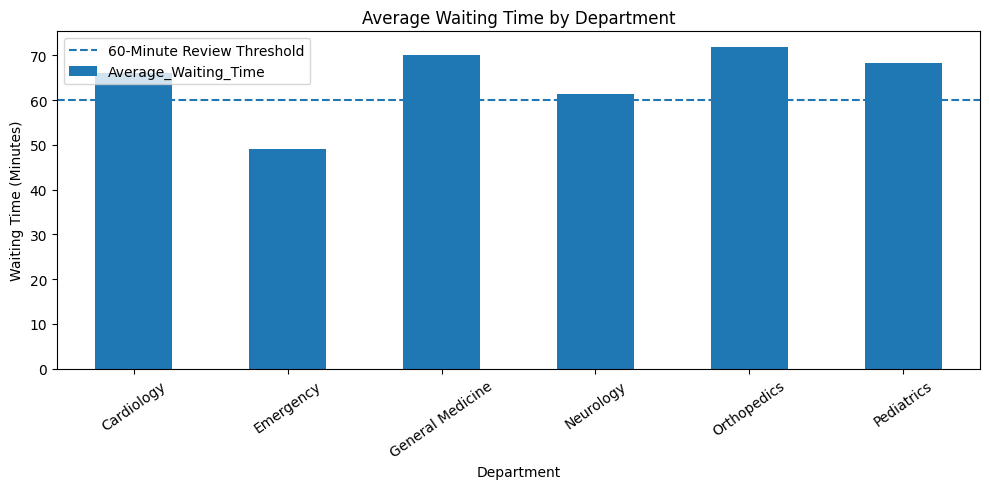


--- OPERATIONAL ALERTS ---
LONG WAITING TIME: Cardiology - Review patient flow and peak-hour coverage.
LONG WAITING TIME: General Medicine - Review patient flow and peak-hour coverage.
LONG WAITING TIME: Neurology - Review patient flow and peak-hour coverage.
LONG WAITING TIME: Orthopedics - Review patient flow and peak-hour coverage.
LONG WAITING TIME: Pediatrics - Review patient flow and peak-hour coverage.

Dataset and department summary saved as CSV files.

PROJECT CONCLUSION

This project analyses healthcare operational data using Python.
It summarises admissions, discharges, occupancy, waiting time,
staff availability and reported incidents.

Charts help compare departments and understand operational trends.
Rule-based alerts highlight areas that may need further review.

The dataset is synthetic and used for demonstration only.
The alerts are illustrative and are not clinical recommendations.



In [2]:
# Healthcare Operations Intelligence Dashboard with Decision Analytics
# Infosys Springboard Virtual Internship Project

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# 2. Create Sample Healthcare Dataset
np.random.seed(42)

departments = [
    "Emergency", "Cardiology", "Neurology",
    "Orthopedics", "General Medicine", "Pediatrics"
]

data = {
    "Date": pd.date_range("2026-01-01", periods=180, freq="D"),
    "Department": np.random.choice(departments, 180),
    "Admissions": np.random.randint(10, 50, 180),
    "Discharges": np.random.randint(8, 45, 180),
    "Occupancy": np.random.randint(50, 101, 180),
    "Waiting_Time": np.random.randint(10, 121, 180),
    "Staff_On_Duty": np.random.randint(5, 25, 180),
    "Incidents": np.random.randint(0, 6, 180)
}

df = pd.DataFrame(data)

print("Healthcare Operations Dataset")
display(df.head())

# 3. Basic Dataset Information
print("Total Records:", len(df))
print("Departments:", df["Department"].nunique())
print("Missing Values:")
print(df.isnull().sum())

# 4. Key Performance Indicators (KPIs)
total_admissions = df["Admissions"].sum()
total_discharges = df["Discharges"].sum()
average_occupancy = df["Occupancy"].mean()
average_waiting_time = df["Waiting_Time"].mean()
total_incidents = df["Incidents"].sum()
average_staff = df["Staff_On_Duty"].mean()

print("\n--- HEALTHCARE KPI SUMMARY ---")
print("Total Admissions:", total_admissions)
print("Total Discharges:", total_discharges)
print("Average Occupancy:", round(average_occupancy, 2), "%")
print("Average Waiting Time:", round(average_waiting_time, 2), "minutes")
print("Average Staff on Duty:", round(average_staff, 2))
print("Total Reported Incidents:", total_incidents)

# 5. Department-wise Analysis
department_summary = df.groupby("Department").agg(
    Total_Admissions=("Admissions", "sum"),
    Total_Discharges=("Discharges", "sum"),
    Average_Occupancy=("Occupancy", "mean"),
    Average_Waiting_Time=("Waiting_Time", "mean"),
    Average_Staff=("Staff_On_Duty", "mean"),
    Total_Incidents=("Incidents", "sum")
).round(2)

print("\n--- DEPARTMENT PERFORMANCE ---")
display(department_summary)

# 6. Admissions and Discharges Trend
daily_summary = df.groupby("Date")[
    ["Admissions", "Discharges"]
].sum()

daily_summary.plot(figsize=(12, 5), marker=".")
plt.title("Daily Patient Admissions and Discharges")
plt.xlabel("Date")
plt.ylabel("Number of Patients")
plt.grid(True)
plt.show()

# 7. Department-wise Occupancy
department_summary["Average_Occupancy"].plot(
    kind="bar", figsize=(10, 5)
)
plt.axhline(y=85, linestyle="--", label="85% Review Threshold")
plt.title("Average Occupancy by Department")
plt.xlabel("Department")
plt.ylabel("Occupancy (%)")
plt.legend()
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

# 8. Waiting Time Analysis
department_summary["Average_Waiting_Time"].plot(
    kind="bar", figsize=(10, 5)
)
plt.axhline(y=60, linestyle="--", label="60-Minute Review Threshold")
plt.title("Average Waiting Time by Department")
plt.xlabel("Department")
plt.ylabel("Waiting Time (Minutes)")
plt.legend()
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

# 9. Decision Analytics and Alerts
print("\n--- OPERATIONAL ALERTS ---")

alerts_found = 0

for department, row in department_summary.iterrows():

    if row["Average_Occupancy"] >= 85:
        print(
            "HIGH OCCUPANCY:",
            department,
            "- Review bed availability and staffing."
        )
        alerts_found += 1

    if row["Average_Waiting_Time"] >= 60:
        print(
            "LONG WAITING TIME:",
            department,
            "- Review patient flow and peak-hour coverage."
        )
        alerts_found += 1

    if row["Total_Incidents"] >= 100:
        print(
            "INCIDENT REVIEW:",
            department,
            "- Review incident trends and documentation."
        )
        alerts_found += 1

if alerts_found == 0:
    print("No operational alerts triggered.")

# 10. Export Results
df.to_csv("healthcare_operations_data.csv", index=False)
department_summary.to_csv(
    "department_performance_summary.csv"
)

print("\nDataset and department summary saved as CSV files.")

# 11. Project Conclusion
print("""
PROJECT CONCLUSION

This project analyses healthcare operational data using Python.
It summarises admissions, discharges, occupancy, waiting time,
staff availability and reported incidents.

Charts help compare departments and understand operational trends.
Rule-based alerts highlight areas that may need further review.

The dataset is synthetic and used for demonstration only.
The alerts are illustrative and are not clinical recommendations.
""")

In [4]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=department_summary)

https://docs.google.com/spreadsheets/d/1RVPfvy_fTySpO9qRqMc6lWkrEdFx1tcaF5_VATtu61g/edit#gid=0
